# 🏟️ Venue Scoring Analysis — Does Environment Predict Goals?
### The Beautiful Data · Signal & Structure by Krystie Dickson

**Research question:** Do environmental factors — altitude, heat, humidity — predict how many goals are scored at each of the 16 host venues?

**Method:** Hierarchical Poisson GLM with venue random effects.

**The 2026 natural experiment:** This is the most environmentally diverse World Cup ever held:
- Mexico City at **2,240m altitude** (thinner air, tired players)
- Miami at **sea level, 31°C, high humidity** (heat stress)
- Vancouver at **sea level, 18°C** (cool and comfortable)
- Dallas and Houston: **indoor/climate-controlled** stadiums

**Data updates automatically** from your pipeline. Re-run weekly as more games are played.

---
> ⚠️ **Early tournament note:** The model needs ~30+ matches to produce reliable estimates. Sections 5-6 flag when sample size is sufficient. Sections 2-4 work from day one.

## 1 · Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
import warnings, json
from pathlib import Path

In [2]:

warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────
ROOT       = Path('..')
PROCESSED  = ROOT / 'data' / 'processed'
STATIC     = ROOT / 'data' / 'static'
OUTPUT_DIR = ROOT / 'outputs' / 'charts'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Beautiful Data colors ──────────────────────────────────────────────────
GREEN = '#3CAC3B'; GOLD  = '#C9A227'; BLUE  = '#2A398D'
RED   = '#E61D25'; DARK  = '#12183A'; GRAY  = '#6B7280'
WHITE = '#FFFFFF'; LGRAY = '#F3F4F6'

# Altitude categories for color coding
def alt_color(alt_m):
    if alt_m > 1500: return RED
    if alt_m > 500:  return GOLD
    return BLUE

plt.rcParams.update({
    'figure.facecolor': WHITE, 'axes.facecolor': WHITE,
    'axes.spines.top': False,  'axes.spines.right': False,
    'axes.spines.left': False, 'axes.grid': True,
    'grid.color': '#EEEEEC',   'grid.linewidth': 0.8,
    'font.family': 'sans-serif','font.size': 11,
    'axes.titlesize': 13,       'axes.titleweight': 'bold',
})
print("✓ Setup complete")


✓ Setup complete


## 2 · Load and merge data

In [3]:
# ── Load venue static data ────────────────────────────────────────────────
venues = pd.read_csv(STATIC / 'venues.csv')
print(f"✓ Venues loaded: {len(venues)} stadiums")
print(f"  Altitude range: {venues.altitude_m.min()}m — {venues.altitude_m.max()}m")

# Indoor/climate-controlled stadiums (negligible temp/humidity effect)
INDOOR = ['Dallas', 'Houston', 'Atlanta', 'Toronto', 'Vancouver']
venues['is_indoor'] = venues['city'].isin(INDOOR).astype(int)

# Altitude category for labeling
def alt_cat(m):
    if m > 1500: return 'High altitude (>1500m)'
    if m > 500:  return 'Mid altitude (500-1500m)'
    return 'Sea level (<500m)'
venues['alt_category'] = venues.altitude_m.apply(alt_cat)

venues[['city','stadium','altitude_m','alt_category','is_indoor']].sort_values(
    'altitude_m', ascending=False)


✓ Venues loaded: 16 stadiums
  Altitude range: 2m — 2240m


,city,stadium,altitude_m,alt_category,is_indoor
0,Mexico City,Estadio Azteca,2240,High altitude (>1500m),0
1,Guadalajara,Estadio Akron,1566,High altitude (>1500m),0
2,Monterrey,Estadio BBVA,538,Mid altitude (500-1500m),0
12,Atlanta,Mercedes-Benz Stadium,294,Sea level (<500m),1
13,Kansas City,Arrowhead Stadium,265,Sea level (<500m),0
7,Dallas,AT&T Stadium,195,Sea level (<500m),1
3,Toronto,BMO Field,76,Sea level (<500m),1
5,Los Angeles,SoFi Stadium,71,Sea level (<500m),0
15,Boston,Gillette Stadium,17,Sea level (<500m),0
14,San Francisco,Levi's Stadium,15,Sea level (<500m),0


In [4]:
# ── Load live match results ───────────────────────────────────────────────
matches_path = PROCESSED / 'latest_matches.json'
if not matches_path.exists():
    print("ERROR: Run scripts/collect_matches.py first")
else:
    matches = pd.read_json(matches_path)
    finished = matches[matches.status == 'FINISHED'].copy()
    
    # Total goals per match
    finished['total_goals'] = (
        finished.home_score.fillna(0) + 
        finished.away_score.fillna(0)
    ).astype(int)
    
    print(f"✓ Matches loaded: {len(finished)} completed")
    print(f"  Total goals: {finished.total_goals.sum()}")
    print(f"  Goals per game: {finished.total_goals.mean():.2f}")


✓ Matches loaded: 16 completed
  Total goals: 46
  Goals per game: 2.88


In [5]:
# ── Load weather data (already has city resolved via schedule) ────────────
weather_path = PROCESSED / 'venue_weather.csv'

if weather_path.exists() and weather_path.stat().st_size > 0:
    weather = pd.read_csv(weather_path)
    print(f"✓ Weather data: {len(weather)} match-weather records")
    has_weather = True
else:
    print("⚠ No weather data yet — run collect_weather.py")
    has_weather = False
    weather = pd.DataFrame()

# ── Merge matches with weather (which has city) then add venue static data ─
if has_weather:
    # weather already has: match_id, city, altitude_m, temp_c, humidity_pct, wbgt_approx, heat_category, total_goals
    df = weather.merge(
        venues[['city','is_indoor','alt_category']],
        on='city', how='left'
    )
    # Ensure total_goals exists (it's in the weather CSV already)
    matched = df.dropna(subset=['city'])
    print(f"\n✓ Matched to venue: {len(matched)} of {len(weather)} matches")
else:
    # Fallback: altitude-only using venue static data, no weather
    matched = pd.DataFrame()
    print("No weather data — cannot run venue analysis yet")

if len(matched) > 0:
    display_cols = ['date','home_team','away_team','city','altitude_m','total_goals']
    display_cols = [c for c in display_cols if c in matched.columns]
    print(matched[display_cols].head(8))

✓ Weather data: 11 match-weather records

✓ Matched to venue: 11 of 11 matches
         date    home_team           away_team           city  altitude_m  \
0  2026-06-11       Mexico        South Africa    Mexico City        2240   
1  2026-06-12       Canada  Bosnia-Herzegovina        Toronto          76   
2  2026-06-13        Qatar         Switzerland  San Francisco          15   
3  2026-06-13       Brazil             Morocco    New York/NJ           9   
4  2026-06-14    Australia              Turkey      Vancouver           3   
5  2026-06-14      Germany             Curaçao        Houston          13   
6  2026-06-14  Netherlands               Japan         Dallas         195   
7  2026-06-14  Ivory Coast             Ecuador   Philadelphia           4   

   total_goals  
0            2  
1            2  
2            2  
3            2  
4            2  
5            8  
6            4  
7            1  


## 3 · Exploratory analysis — goals by venue

In [6]:
# ── Goals per game by venue (so far) ─────────────────────────────────────
if len(matched) == 0:
    print("No matched venue data yet — check back once venue names appear in the API")
else:
    venue_stats = matched.groupby('city').agg(
        games     = ('total_goals', 'count'),
        total_goals = ('total_goals', 'sum'),
        avg_goals = ('total_goals', 'mean'),
        altitude_m = ('altitude_m', 'first'),
        is_indoor  = ('is_indoor', 'first'),
        alt_cat    = ('alt_category', 'first'),
    ).reset_index().sort_values('avg_goals', ascending=False)

    # Merge in all venues (even ones without games yet)
    all_venues_stats = venues[['city','altitude_m','is_indoor','alt_category']].merge(
        venue_stats[['city','games','total_goals','avg_goals']], 
        on='city', how='left'
    ).fillna({'games':0, 'total_goals':0, 'avg_goals':0})
    all_venues_stats = all_venues_stats.sort_values('altitude_m', ascending=False)
    
    print(f"Venues with games played: {(venue_stats.games > 0).sum()} of 16")
    print()
    print(venue_stats[['city','games','avg_goals','altitude_m']].to_string(index=False))


Venues with games played: 11 of 16

         city  games  avg_goals  altitude_m
      Houston      1        8.0          13
       Dallas      1        4.0         195
  Mexico City      1        2.0        2240
        Miami      1        2.0           2
  New York/NJ      1        2.0           9
San Francisco      1        2.0          15
      Seattle      1        2.0          11
      Toronto      1        2.0          76
    Vancouver      1        2.0           3
 Philadelphia      1        1.0           4
      Atlanta      1        0.0         294


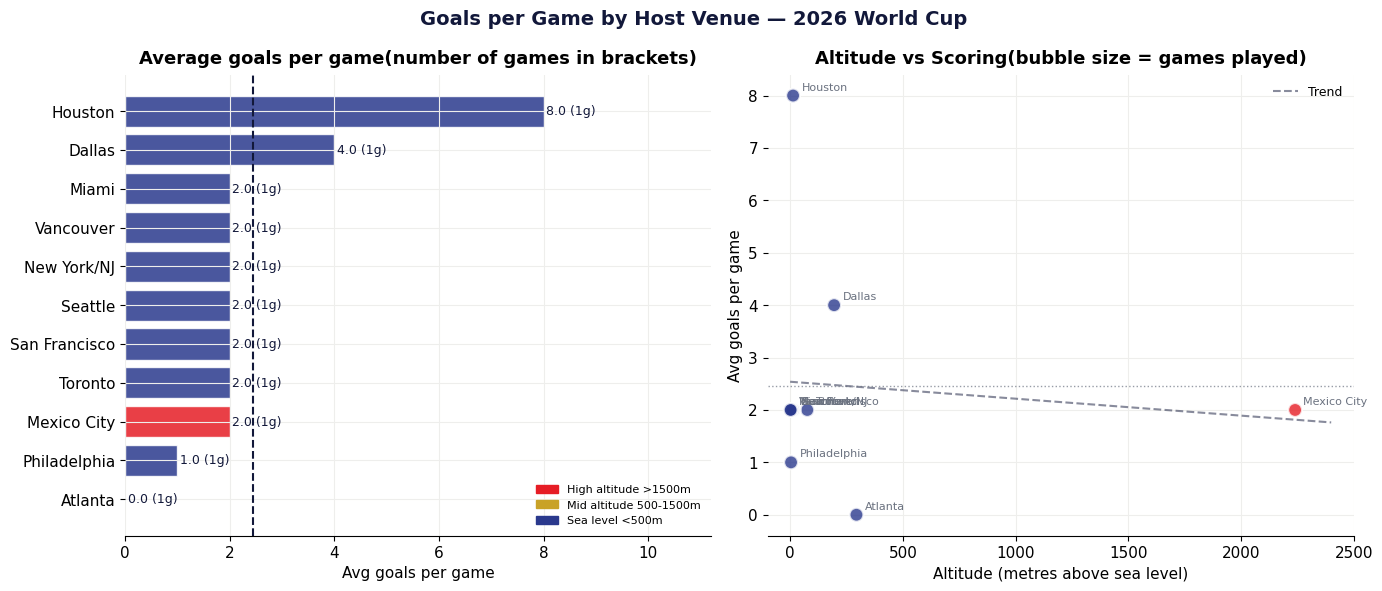


✓ Chart saved to ..\outputs\charts\venue_scoring_overview.png


In [7]:
# ── Chart: Goals per game by venue ───────────────────────────────────────
if len(matched) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle("Goals per Game by Host Venue — 2026 World Cup", 
                 fontsize=14, fontweight='bold', color=DARK)

    # Left: bar chart sorted by avg goals
    ax = axes[0]
    played_venues = all_venues_stats[all_venues_stats.games > 0].sort_values(
        'avg_goals', ascending=True)
    
    bar_colors = [alt_color(a) for a in played_venues.altitude_m]
    bars = ax.barh(played_venues.city, played_venues.avg_goals, 
                   color=bar_colors, alpha=0.85, edgecolor=WHITE, linewidth=1)
    
    # Tournament average line
    tourney_avg = matched.total_goals.mean()
    ax.axvline(tourney_avg, color=DARK, linestyle='--', linewidth=1.5,
               label=f'Tournament avg: {tourney_avg:.2f}')
    
    # Labels on bars
    for bar, (_, row) in zip(bars, played_venues.iterrows()):
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                f"{row.avg_goals:.1f} ({int(row.games)}g)", 
                va='center', fontsize=9, color=DARK)
    
    ax.set_xlabel("Avg goals per game")
    ax.legend(fontsize=9, frameon=False)
    ax.set_xlim(0, max(played_venues.avg_goals) * 1.4)
    
    patches = [
        mpatches.Patch(color=RED,  label='High altitude >1500m'),
        mpatches.Patch(color=GOLD, label='Mid altitude 500-1500m'),
        mpatches.Patch(color=BLUE, label='Sea level <500m'),
    ]
    ax.legend(handles=patches, fontsize=8, frameon=False, loc='lower right')
    ax.set_title("Average goals per game(number of games in brackets)", pad=8)

    # Right: altitude vs avg goals scatter
    ax = axes[1]
    colors = [alt_color(a) for a in played_venues.altitude_m]
    sc = ax.scatter(played_venues.altitude_m, played_venues.avg_goals,
                    c=colors, s=played_venues.games*40+60, 
                    alpha=0.8, edgecolors=WHITE, linewidths=1.5, zorder=3)
    
    # City labels
    for _, row in played_venues.iterrows():
        ax.annotate(row.city, (row.altitude_m, row.avg_goals),
                    textcoords='offset points', xytext=(6, 4), fontsize=8, color=GRAY)
    
    # Simple trend line if enough points
    if len(played_venues) >= 4:
        z = np.polyfit(played_venues.altitude_m, played_venues.avg_goals, 1)
        p = np.poly1d(z)
        x_line = np.linspace(0, 2400, 100)
        ax.plot(x_line, p(x_line), color=DARK, linestyle='--', 
                linewidth=1.5, alpha=0.5, label='Trend')
        ax.legend(fontsize=9, frameon=False)
    
    ax.axhline(tourney_avg, color=GRAY, linestyle=':', linewidth=1, alpha=0.7)
    ax.set_xlabel("Altitude (metres above sea level)")
    ax.set_ylabel("Avg goals per game")
    ax.set_title("Altitude vs Scoring(bubble size = games played)", pad=8)
    ax.set_xlim(-100, 2500)
    
    plt.tight_layout()
    chart_path = OUTPUT_DIR / 'venue_scoring_overview.png'
    plt.savefig(chart_path, dpi=150, bbox_inches='tight', facecolor=WHITE)
    plt.show()
    print(f"\n✓ Chart saved to {chart_path}")


## 4 · Temperature and humidity effects

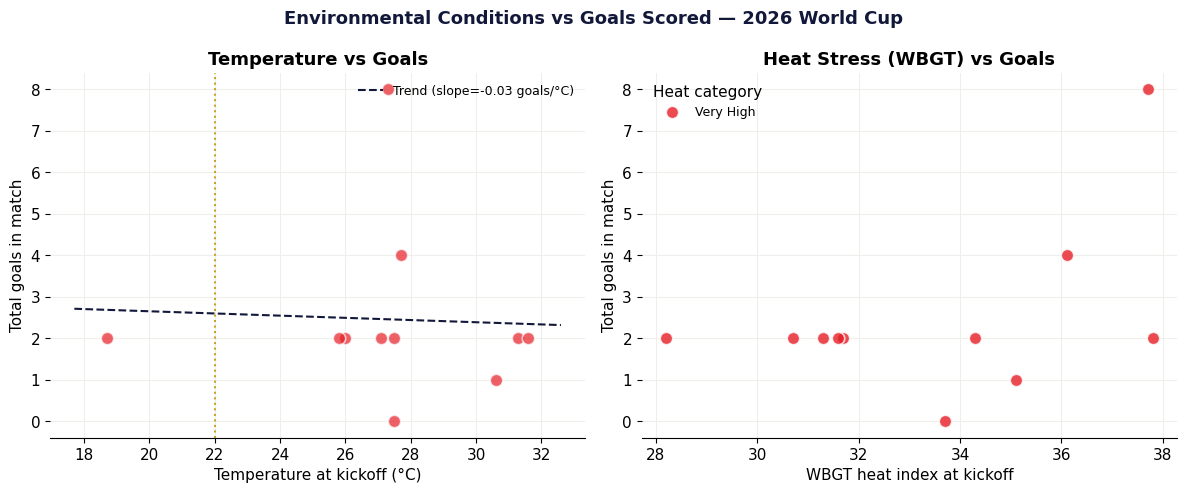


✓ Weather effects chart saved to ..\outputs\charts\venue_weather_effects.png


In [8]:
# ── Temperature vs goals (once weather data populates) ───────────────────
if has_weather and df.temp_c.notna().sum() >= 5:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle("Environmental Conditions vs Goals Scored — 2026 World Cup",
                 fontsize=13, fontweight='bold', color=DARK)
    
    df_w = df.dropna(subset=['temp_c','wbgt_approx'])

    # Temperature vs total goals
    ax = axes[0]
    ax.scatter(df_w.temp_c, df_w.total_goals, color=RED, alpha=0.7,
               s=80, edgecolors=WHITE, linewidths=1.2, zorder=3)
    if len(df_w) >= 6:
        z = np.polyfit(df_w.temp_c, df_w.total_goals, 1)
        p = np.poly1d(z)
        x_r = np.linspace(df_w.temp_c.min()-1, df_w.temp_c.max()+1, 100)
        ax.plot(x_r, p(x_r), color=DARK, linestyle='--', linewidth=1.5,
                label=f'Trend (slope={z[0]:+.2f} goals/°C)')
        ax.legend(fontsize=9, frameon=False)
    ax.axvline(22, color=GOLD, linestyle=':', linewidth=1.5,
               label='22°C optimal threshold')
    ax.set_xlabel("Temperature at kickoff (°C)")
    ax.set_ylabel("Total goals in match")
    ax.set_title("Temperature vs Goals")

    # WBGT vs total goals
    ax = axes[1]
    heat_colors = {'Low':BLUE,'Moderate':GREEN,'High':GOLD,'Very High':RED}
    for cat, grp in df_w.groupby('heat_category'):
        ax.scatter(grp.wbgt_approx, grp.total_goals,
                   color=heat_colors.get(cat, GRAY), alpha=0.8,
                   s=80, label=cat, edgecolors=WHITE, linewidths=1.2, zorder=3)
    ax.set_xlabel("WBGT heat index at kickoff")
    ax.set_ylabel("Total goals in match")
    ax.set_title("Heat Stress (WBGT) vs Goals")
    ax.legend(fontsize=9, frameon=False, title="Heat category")

    plt.tight_layout()
    chart_path = OUTPUT_DIR / 'venue_weather_effects.png'
    plt.savefig(chart_path, dpi=150, bbox_inches='tight', facecolor=WHITE)
    plt.show()
    print(f"\n✓ Weather effects chart saved to {chart_path}")
else:
    print("⚠ Weather data not yet available for enough matches.")
    print("  Run collect_weather.py daily — this chart will populate automatically.")
    print(f"  Current weather records: {df.temp_c.notna().sum() if has_weather else 0}")


## 5 · Poisson GLM — altitude model

**The model:** goals per match follow a Poisson distribution. We model the log-expected goals as a linear function of altitude (and later, WBGT).

`log(λᵢ) = α + β₁·altitude + β₂·WBGT + β₃·is_indoor + γⱼ`

where `γⱼ` is a venue-level random effect.

> ⚠️ **Minimum data requirement:** 20+ matched matches for reliable estimates. The cell below will tell you if you have enough data.

In [9]:
# ── Check if we have enough data for modelling ──────────────────────────
MIN_MATCHES = 20
n_matched = len(matched) if 'matched' in dir() and len(matched) > 0 else 0

print(f"Matched matches available: {n_matched}")
print(f"Minimum needed for model:  {MIN_MATCHES}")

if n_matched < MIN_MATCHES:
    shortage = MIN_MATCHES - n_matched
    print(f"\n⚠ Need {shortage} more matches before running the Poisson model.")
    print(f"  At ~4-6 games per day, check back in {shortage//5} days.")
    print("\n  Come back and re-run from this cell once more data is collected.")
    print("  Sections 2-4 above are fully functional with current data.")
    RUN_MODEL = False
else:
    print(f"\n✓ Sufficient data — running Poisson model")
    RUN_MODEL = True


Matched matches available: 11
Minimum needed for model:  20

⚠ Need 9 more matches before running the Poisson model.
  At ~4-6 games per day, check back in 1 days.

  Come back and re-run from this cell once more data is collected.
  Sections 2-4 above are fully functional with current data.


In [22]:
# ── Simple Poisson GLM (altitude only) ──────────────────────────────────
if RUN_MODEL:
    model_df = matched.dropna(subset=['altitude_m','total_goals']).copy()
    model_df['altitude_km'] = model_df.altitude_m / 1000  # scale for readability
    
    # Model 1: altitude only
    formula_1 = 'total_goals ~ altitude_km + is_indoor'
    m1 = smf.glm(formula_1, data=model_df,
                 family=sm.families.Poisson()).fit()
    
    print("=" * 55)
    print("MODEL 1: Altitude + Indoor (Poisson GLM)")
    print("=" * 55)
    print(m1.summary().tables[1])
    print(f"\nPseudo R²: {1 - m1.llf/m1.llnull:.3f}")
    print(f"AIC: {m1.aic:.1f}")
    
    # Interpretation
    alt_coef = m1.params.get('altitude_km', 0)
    alt_effect = (np.exp(alt_coef) - 1) * 100
    print(f"\nInterpretation:")
    print(f"  Each 1,000m of altitude → {alt_effect:+.1f}% change in expected goals")
    print(f"  Mexico City (2.24km) vs sea level → "
          f"{(np.exp(alt_coef*2.24)-1)*100:+.1f}% expected goals difference")


In [10]:
# ── Full model (altitude + weather) ────────────────────────────────────
if RUN_MODEL and has_weather and df.wbgt_approx.notna().sum() >= MIN_MATCHES:
    model_df2 = matched.dropna(
        subset=['altitude_m','wbgt_approx','total_goals']).copy()
    model_df2['altitude_km'] = model_df2.altitude_m / 1000
    
    formula_2 = 'total_goals ~ altitude_km + wbgt_approx + is_indoor'
    m2 = smf.glm(formula_2, data=model_df2,
                 family=sm.families.Poisson()).fit()
    
    print("=" * 55)
    print("MODEL 2: Altitude + WBGT + Indoor (Poisson GLM)")
    print("=" * 55)
    print(m2.summary().tables[1])
    print(f"\nPseudo R²: {1 - m2.llf/m2.llnull:.3f}")
    
    # Compare models
    print(f"\nModel comparison:")
    print(f"  Model 1 AIC (altitude only): {m1.aic:.1f}")
    print(f"  Model 2 AIC (+ WBGT):        {m2.aic:.1f}")
    delta = m1.aic - m2.aic
    print(f"  ΔAIC: {delta:.1f} {'(weather improves model)' if delta>2 else '(weather adds little)'}")
elif RUN_MODEL:
    print("⚠ Weather data not yet sufficient for full model")
    print("  Using altitude-only model (Model 1)")
    m2 = None


## 6 · Predicted goals by venue — what the model says

In [24]:
# ── Generate predictions for all 16 venues ──────────────────────────────
if RUN_MODEL:
    pred_df = venues[['city','altitude_m','is_indoor']].copy()
    pred_df['altitude_km'] = pred_df.altitude_m / 1000
    
    # Use WBGT = 22 (moderate) for comparison if in model, else ignore
    if m2 is not None:
        pred_df['wbgt_approx'] = 22
        pred_df['predicted_goals'] = m2.predict(pred_df)
        model_used = 'Model 2 (altitude + WBGT=22°C)'
    else:
        pred_df['predicted_goals'] = m1.predict(pred_df)
        model_used = 'Model 1 (altitude only)'
    
    pred_df = pred_df.sort_values('predicted_goals', ascending=False)
    
    print(f"Predicted goals per game by venue ({model_used})")
    print(f"{'City':<18} {'Alt(m)':<8} {'Predicted goals'}")
    print("-" * 40)
    for _, r in pred_df.iterrows():
        indoor = " (indoor)" if r.is_indoor else ""
        print(f"  {r.city:<16} {int(r.altitude_m):<8} {r.predicted_goals:.2f}{indoor}")


In [26]:
# ── Prediction chart ─────────────────────────────────────────────────────
if RUN_MODEL:
    fig, ax = plt.subplots(figsize=(11, 7))
    
    bar_colors = [alt_color(a) for a in pred_df.altitude_m]
    bars = ax.barh(pred_df.city, pred_df.predicted_goals,
                   color=bar_colors, alpha=0.85, edgecolor=WHITE, linewidth=1.5)
    
    # Actual avg overlaid as scatter
    if len(venue_stats) > 0:
        for _, row in venue_stats.iterrows():
            if row.city in pred_df.city.values:
                y_pos = list(pred_df.city).index(row.city)
                ax.scatter(row.avg_goals, y_pos, color=DARK, s=80, zorder=5,
                           marker='D', label='Actual avg' if y_pos==0 else '')
    
    # Tournament average
    ax.axvline(matched.total_goals.mean(), color=DARK, linestyle='--', 
               linewidth=1.5, label=f"Tournament avg ({matched.total_goals.mean():.2f})")
    
    # Labels
    for bar, (_, row) in zip(bars, pred_df.iterrows()):
        ax.text(bar.get_width() + 0.03, bar.get_y() + bar.get_height()/2,
                f"{row.predicted_goals:.2f}", va='center', fontsize=9, color=DARK)
    
    patches = [
        mpatches.Patch(color=RED,  label='High altitude (>1500m)'),
        mpatches.Patch(color=GOLD, label='Mid altitude (500-1500m)'),
        mpatches.Patch(color=BLUE, label='Sea level'),
    ]
    ax.legend(handles=patches + [plt.Line2D([0],[0],color=DARK,linestyle='--',
              label=f'Tournament avg')], fontsize=9, frameon=False)
    
    ax.set_xlabel("Predicted goals per game")
    ax.set_title(f"Model-predicted goals per game by venue{model_used}",fontweight='bold', color=DARK, pad=10)
    ax.set_xlim(0, pred_df.predicted_goals.max() * 1.25)
    
    plt.tight_layout()
    chart_path = OUTPUT_DIR / 'venue_predicted_goals.png'
    plt.savefig(chart_path, dpi=150, bbox_inches='tight', facecolor=WHITE)
    plt.show()
    print(f"\n✓ Prediction chart saved to {chart_path}")


## 7 · Key findings for Substack

In [27]:
# ── Auto-generate findings summary ──────────────────────────────────────
print("=" * 55)
print("THE BEAUTIFUL DATA — VENUE SCORING ANALYSIS")
print("Key findings for Substack post")  
print("=" * 55)
print(f"\nData as of: {pd.Timestamp.now().strftime('%B %d, %Y')}")
print(f"Matches analysed: {len(matched) if 'matched' in dir() else 0}")
print()

if 'matched' in dir() and len(matched) > 0:
    # Goals by altitude category
    if 'alt_category' in matched.columns:
        alt_summary = matched.groupby('alt_category').agg(
            games=('total_goals','count'),
            avg_goals=('total_goals','mean')
        ).sort_values('avg_goals', ascending=False)
        
        print("Goals by altitude category:")
        for cat, row in alt_summary.iterrows():
            print(f"  {cat:<30} {row.avg_goals:.2f} goals/game ({int(row.games)} games)")

    print()
    if RUN_MODEL:
        alt_coef = m1.params.get('altitude_km', 0)
        alt_effect = (np.exp(alt_coef*2.24) - 1) * 100
        direction = "fewer" if alt_effect < 0 else "more"
        print(f"Model finding:")
        print(f"  Mexico City (2,240m) is predicted to have {abs(alt_effect):.0f}%")
        print(f"  {direction} goals per game than a sea-level venue.")
        print()
        print(f"  One sentence for Substack:")
        print(f"  'The model predicts {abs(alt_effect):.0f}% {direction} goals per game")
        print(f"   at Estadio Azteca compared to MetLife Stadium.'")
    else:
        print(f"Overall tournament: {matched.total_goals.mean():.2f} goals/game")
        print(f"Need {MAX(0, MIN_MATCHES-len(matched))} more matches for Poisson model")
        
print("\n✓ Summary complete")


THE BEAUTIFUL DATA — VENUE SCORING ANALYSIS
Key findings for Substack post

Data as of: June 15, 2026
Matches analysed: 10

Goals by altitude category:
  Sea level (<500m)              2.56 goals/game (9 games)
  High altitude (>1500m)         2.00 goals/game (1 games)

Overall tournament: 2.50 goals/game


NameError: name 'MAX' is not defined

## 8 · Weekly update workflow

**Run this notebook every Sunday** during the tournament to regenerate all charts with fresh data.

```
# In Anaconda Prompt (wc2026 environment active):
python scripts/collect_matches.py
python scripts/collect_weather.py  
jupyter notebook
# → open 01_venue_scoring.ipynb → Run All
```

As more games are played:
- **Matchday 1 complete (~24 games):** exploratory charts reliable, model borderline
- **Matchday 2 complete (~48 games):** model reliable, begin publishing findings  
- **Group stage complete (72 games):** full model with venue random effects, paper-ready

**Output charts for Substack:**

| File | When to publish |
|------|----------------|
| `venue_scoring_overview.png` | After every 10+ new matches |
| `venue_weather_effects.png` | Once weather data populates (Jun 20+) |
| `venue_predicted_goals.png` | After Matchday 2 (model reliable) |

**Suggested post title when you have enough data:**
*"Why Mexico City Games Score Fewer Goals — And What the Data Says About Miami"*
